# Lipschitz of the score

We care about the jacobian of the score and its eigenvectors for distributions on a manifold with small gaussian noise added.

Let
$$
p_\sigma(x)
=
(p * \varphi_\sigma)(x)
=
\int_{\mathbb{R}^d}
p(y)\,
\frac{1}{(2\pi \sigma^2)^{d/2}}
\exp\!\left(
-\frac{\|x-y\|^2}{2\sigma^2}
\right)\,dy.
$$

Then the score of the Gaussian-smoothed density is

$$
\nabla \log p_\sigma(x)
=
\frac{
\displaystyle
\int_{\mathbb{R}^d}
\frac{y-x}{\sigma^2}\,
p(y)\,
\varphi_\sigma(x-y)\,dy
}{
\displaystyle
\int_{\mathbb{R}^d}
p(y)\,
\varphi_\sigma(x-y)\,dy
}.
$$

Equivalently, if
$$
Y \sim p,
\qquad
X = Y + \sigma Z,
\qquad
Z \sim \mathcal N(0,I),
$$
then

$$
\nabla \log p_\sigma(x)
=
\frac{1}{\sigma^2}
\left(
\mathbb E[Y \mid X=x] - x
\right).
$$

# Closed-Form Hessian of a Noise-Perturbed Density

## 1. System Setup and Definitions

Let $y \in \mathbb{R}^d$ be a random variable distributed according to an arbitrary data distribution $p(y)$. Let $x \in \mathbb{R}^d$ be the corresponding noise-perturbed variable generated via the conditional distribution:

$$p_\sigma(x|y) = \mathcal{N}(x; y, \sigma^2 I_d) = \frac{1}{(2\pi\sigma^2)^{d/2}} \exp\left( -\frac{\|x - y\|^2}{2\sigma^2} \right)$$

The marginal distribution $p_\sigma(x)$ is defined by the convolution:

$$p_\sigma(x) = \int_{\mathbb{R}^d} p(y) p_\sigma(x|y) \, dy$$

By Bayes' theorem, the posterior distribution of the clean data $y$ given the observed noisy vector $x$ is:

$$p_\sigma(y|x) = \frac{p(y) p_\sigma(x|y)}{p_\sigma(x)}$$


## 2. Main Theorem

The Hessian matrix of the log-density $\log p_\sigma(x)$ with respect to $x$ is given exactly by the expression:

$$\nabla_x^2 \log p_\sigma(x) = \frac{1}{\sigma^4} \operatorname{Cov}_{y \sim p_\sigma(y|x)}(y) - \frac{1}{\sigma^2} I_d$$

where $\operatorname{Cov}_{y \sim p_\sigma(y|x)}(y) \in \mathbb{R}^{d \times d}$ is the conditional covariance matrix of the clean data given the noisy observation:

$$\operatorname{Cov}_{y \sim p_\sigma(y|x)}(y) = \mathbb{E}_{y \sim p_\sigma(y|x)}\left[ y y^T \right] - \mathbb{E}_{y \sim p_\sigma(y|x)}[y] \mathbb{E}_{y \sim p_\sigma(y|x)}[y]^T$$


## 3.  Derivation

### Step 3.1: First-Order Derivative (The Score Function)
We begin by evaluating the spatial gradient of the log-marginal density:

$$\text{score}(x) = \nabla_x \log p_\sigma(x) = \frac{\nabla_x p_\sigma(x)}{p_\sigma(x)}$$

Differentiating the convolution integral under the integral sign yields:

$$\nabla_x p_\sigma(x) = \int_{\mathbb{R}^d} p(y) \nabla_x p_\sigma(x|y) \, dy$$

The gradient of the Gaussian kernel with respect to $x$ is:

$$\nabla_x p_\sigma(x|y) = p_\sigma(x|y) \left( \frac{y - x}{\sigma^2} \right)$$

Substituting this back into the gradient equation and normalizing by $p_\sigma(x)$ provides:

$$\begin{aligned}
\nabla_x \log p_\sigma(x) &= \int_{\mathbb{R}^d} \frac{p(y) p_\sigma(x|y)}{p_\sigma(x)} \left( \frac{y - x}{\sigma^2} \right) \, dy \\
&= \int_{\mathbb{R}^d} p_\sigma(y|x) \left( \frac{y - x}{\sigma^2} \right) \, dy \\
&= \frac{\mathbb{E}_{y \sim p_\sigma(y|x)}[y] - x}{\sigma^2}
\end{aligned}$$

> **Tweedie's Formula:**
> $$\nabla_x \log p_\sigma(x) = \frac{\mathbb{E}_{y \sim p_\sigma(y|x)}[y] - x}{\sigma^2}$$

### Step 3.2: Jacobian of the Posterior Expectation
To compute the Hessian, we must differentiate the score function with respect to $x$:

$$\nabla_x^2 \log p_\sigma(x) = \nabla_x \left( \frac{\mathbb{E}_{y \sim p_\sigma(y|x)}[y] - x}{\sigma^2} \right) = \frac{1}{\sigma^2} \nabla_x \mathbb{E}_{y \sim p_\sigma(y|x)}[y] - \frac{1}{\sigma^2} I_d$$

We isolate and evaluate the Jacobian matrix of the conditional expectation $\mu(x) = \mathbb{E}_{y \sim p_\sigma(y|x)}[y] = \int_{\mathbb{R}^d} y \, p_\sigma(y|x) \, dy$. Utilizing the identity $\nabla_x p_\sigma(y|x) = p_\sigma(y|x) \nabla_x \log p_\sigma(y|x)$, we obtain:

$$\nabla_x \mathbb{E}_{y \sim p_\sigma(y|x)}[y] = \int_{\mathbb{R}^d} y \left[ \nabla_x \log p_\sigma(y|x) \right]^T p_\sigma(y|x) \, dy$$

Expanding the gradient of the log-posterior:

$$\log p_\sigma(y|x) = \log p(y) + \log p_\sigma(x|y) - \log p_\sigma(x)$$

$$\nabla_x \log p_\sigma(y|x) = \frac{y - x}{\sigma^2} - \nabla_x \log p_\sigma(x)$$

Substituting this vector into the integral expression:

$$\begin{aligned}
\nabla_x \mathbb{E}_{y \sim p_\sigma(y|x)}[y] &= \int_{\mathbb{R}^d} y \left( \frac{y - x}{\sigma^2} - \nabla_x \log p_\sigma(x) \right)^T p_\sigma(y|x) \, dy \\
&= \frac{1}{\sigma^2} \mathbb{E}_{y \sim p_\sigma(y|x)}\left[y(y-x)^T\right] - \mathbb{E}_{y \sim p_\sigma(y|x)}[y] \left(\nabla_x \log p_\sigma(x)\right)^T
\end{aligned}$$

### Step 3.3: Second-Order Matrix Expansion
We now substitute Tweedie's formula for the remaining $\nabla_x \log p_\sigma(x)$ term:

$$\begin{aligned}
\nabla_x \mathbb{E}_{y \sim p_\sigma(y|x)}[y] &= \frac{1}{\sigma^2} \left( \mathbb{E}[y y^T] - \mathbb{E}[y]x^T \right) - \mathbb{E}[y] \left( \frac{\mathbb{E}[y]^T - x^T}{\sigma^2} \right) \\
&= \frac{1}{\sigma^2} \mathbb{E}[y y^T] - \frac{1}{\sigma^2} \mathbb{E}[y]x^T - \frac{1}{\sigma^2}\mathbb{E}[y]\mathbb{E}[y]^T + \frac{1}{\sigma^2}\mathbb{E}[y]x^T \\
&= \frac{1}{\sigma^2} \left( \mathbb{E}[y y^T] - \mathbb{E}[y]\mathbb{E}[y]^T \right) \\
&= \frac{1}{\sigma^2} \operatorname{Cov}_{y \sim p_\sigma(y|x)}(y)
\end{aligned}$$

### Step 3.4: Final Substitution
Inserting the isolated Jacobian of the expectation back into the primary Hessian equation yields the final expression:

$$\nabla_x^2 \log p_\sigma(x) = \frac{1}{\sigma^2} \left( \frac{1}{\sigma^2} \operatorname{Cov}_{y \sim p_\sigma(y|x)}(y) \right) - \frac{1}{\sigma^2} I_d = \frac{1}{\sigma^4} \operatorname{Cov}_{y \sim p_\sigma(y|x)}(y) - \frac{1}{\sigma^2} I_d$$

### 1. The Posterior Density on $S^1$

Let the prior $p(y)$ be uniform on the unit circle $S^1 \subset \mathbb{R}^2$, meaning $p(y) = \frac{1}{2\pi}$. The observation $x \in \mathbb{R}^2$ is generated via $x = y + \epsilon$ where $\epsilon \sim \mathcal{N}(0, \sigma^2 I_2)$.

The conditional density of $x$ given $y$ is:


$$p_\sigma(x \mid y) \propto \exp\left( -\frac{\|x - y\|^2}{2\sigma^2} \right) \propto \exp\left( \frac{x^T y}{\sigma^2} \right)$$


where we have absorbed the constant $\exp(-\frac{\|x\|^2 + \|y\|^2}{2\sigma^2})$ (since $\|y\|^2 = 1$) into the proportionality factor.

By Bayes' theorem, the posterior $p_\sigma(y \mid x)$ is proportional to the likelihood:


$$p_\sigma(y \mid x) = \frac{1}{Z(x)} \exp\left( \frac{x^T y}{\sigma^2} \right)$$

### 2. Orthonormal Basis and Parameterization

To evaluate the moments, we construct an orthonormal basis for $\mathbb{R}^2$ aligned with the observation vector $x$. Let:


$$\mathbf{u} = \frac{x}{\|x\|}$$


Let $\mathbf{v}$ be the unit vector orthogonal to $\mathbf{u}$ such that $(\mathbf{u}, \mathbf{v})$ forms a positively oriented orthonormal basis. The resolution of the identity in $\mathbb{R}^2$ gives:


$$I_2 = \mathbf{u}\mathbf{u}^T + \mathbf{v}\mathbf{v}^T \implies \mathbf{v}\mathbf{v}^T = I_2 - \mathbf{u}\mathbf{u}^T$$

Any vector $y \in S^1$ can be parameterized by the angle $\theta \in [-\pi, \pi)$ measured from $\mathbf{u}$:


$$y(\theta) = \cos\theta \mathbf{u} + \sin\theta \mathbf{v}$$

Define the concentration parameter $\lambda = \frac{\|x\|}{\sigma^2}$. The inner product simplifies to:


$$x^T y(\theta) = \|x\| \mathbf{u}^T (\cos\theta \mathbf{u} + \sin\theta \mathbf{v}) = \|x\| \cos\theta$$

Thus, the posterior distribution over $\theta$ is the von Mises distribution:


$$p_\sigma(\theta \mid x) = \frac{1}{Z(x)} \exp(\lambda \cos\theta)$$

The partition function $Z(x)$ is evaluated via the definition of the modified Bessel function of the first kind of order $0$, $I_0(\lambda) = \frac{1}{2\pi}\int_{-\pi}^{\pi} \exp(\lambda \cos\theta) d\theta$:


$$Z(x) = \int_{-\pi}^{\pi} \exp(\lambda \cos\theta) d\theta = 2\pi I_0(\lambda)$$

### 3. Derivation of the First Moment $\mathbb{E}[y \mid x]$

Taking the expectation of $y$:


$$\mathbb{E}[y \mid x] = \frac{1}{2\pi I_0(\lambda)} \int_{-\pi}^{\pi} (\cos\theta \mathbf{u} + \sin\theta \mathbf{v}) \exp(\lambda \cos\theta) d\theta$$

Because the integration domain is symmetric about $0$ and $\exp(\lambda \cos\theta)$ is an even function, the integral over the odd component $\sin\theta \mathbf{v}$ evaluates exactly to zero:


$$\int_{-\pi}^{\pi} \sin\theta \exp(\lambda \cos\theta) d\theta = 0$$

The remaining integral relies on the definition of the modified Bessel function of order $1$, $I_1(\lambda) = \frac{1}{2\pi}\int_{-\pi}^{\pi} \cos\theta \exp(\lambda \cos\theta) d\theta$:


$$\mathbb{E}[y \mid x] = \frac{2\pi I_1(\lambda)}{2\pi I_0(\lambda)} \mathbf{u} = \frac{I_1(\lambda)}{I_0(\lambda)} \frac{x}{\|x\|}$$

Defining the ratio $A(\lambda) = \frac{I_1(\lambda)}{I_0(\lambda)}$, we obtain:


$$\mathbb{E}[y \mid x] = A(\lambda) \frac{x}{\|x\|}$$

### 4. Derivation of the Second Moment Matrix $\mathbb{E}[yy^T \mid x]$

We form the outer product $yy^T$ using our basis representation:


$$y y^T = (\cos\theta \mathbf{u} + \sin\theta \mathbf{v})(\cos\theta \mathbf{u}^T + \sin\theta \mathbf{v}^T)$$

$$y y^T = \cos^2\theta \mathbf{u}\mathbf{u}^T + \sin^2\theta \mathbf{v}\mathbf{v}^T + \cos\theta\sin\theta (\mathbf{u}\mathbf{v}^T + \mathbf{v}\mathbf{u}^T)$$

Taking the conditional expectation, the cross-terms $\cos\theta\sin\theta$ vanish due to odd parity. The second moment reduces to:


$$\mathbb{E}[yy^T \mid x] = \mathbb{E}[\cos^2\theta \mid x] \mathbf{u}\mathbf{u}^T + \mathbb{E}[\sin^2\theta \mid x] \mathbf{v}\mathbf{v}^T$$

Substitute the identity $\mathbf{v}\mathbf{v}^T = I_2 - \mathbf{u}\mathbf{u}^T$:


$$\mathbb{E}[yy^T \mid x] = \mathbb{E}[\cos^2\theta \mid x] \mathbf{u}\mathbf{u}^T + \mathbb{E}[\sin^2\theta \mid x] (I_2 - \mathbf{u}\mathbf{u}^T)$$

$$\mathbb{E}[yy^T \mid x] = \mathbb{E}[\sin^2\theta \mid x] I_2 + \left( \mathbb{E}[\cos^2\theta \mid x] - \mathbb{E}[\sin^2\theta \mid x] \right) \mathbf{u}\mathbf{u}^T$$

We now evaluate the scalar expectations. Since $\cos^2\theta + \sin^2\theta = 1$, we only need to compute $\mathbb{E}[\cos^2\theta \mid x]$:


$$\mathbb{E}[\cos^2\theta \mid x] = \frac{1}{2\pi I_0(\lambda)} \int_{-\pi}^{\pi} \cos^2\theta \exp(\lambda \cos\theta) d\theta$$

Applying the double-angle formula $\cos^2\theta = \frac{1 + \cos(2\theta)}{2}$:


$$\mathbb{E}[\cos^2\theta \mid x] = \frac{1}{2} + \frac{1}{2} \left( \frac{1}{2\pi I_0(\lambda)} \int_{-\pi}^{\pi} \cos(2\theta) \exp(\lambda \cos\theta) d\theta \right)$$

The remaining integral is exactly the modified Bessel function of order $2$:


$$\mathbb{E}[\cos^2\theta \mid x] = \frac{1}{2} \left( 1 + \frac{I_2(\lambda)}{I_0(\lambda)} \right)$$

We invoke the standard recurrence relation for modified Bessel functions, $I_{\nu-1}(\lambda) - I_{\nu+1}(\lambda) = \frac{2\nu}{\lambda} I_\nu(\lambda)$. For $\nu = 1$:


$$I_0(\lambda) - I_2(\lambda) = \frac{2}{\lambda} I_1(\lambda)$$

Dividing both sides by $I_0(\lambda)$ and isolating the order $2$ ratio:


$$\frac{I_2(\lambda)}{I_0(\lambda)} = 1 - \frac{2}{\lambda} \frac{I_1(\lambda)}{I_0(\lambda)} = 1 - \frac{2}{\lambda} A(\lambda)$$

Substitute this into the expectation of $\cos^2\theta$:


$$\mathbb{E}[\cos^2\theta \mid x] = \frac{1}{2} \left( 1 + 1 - \frac{2}{\lambda} A(\lambda) \right) = 1 - \frac{A(\lambda)}{\lambda}$$

Consequently, by the Pythagorean identity:


$$\mathbb{E}[\sin^2\theta \mid x] = 1 - \mathbb{E}[\cos^2\theta \mid x] = \frac{A(\lambda)}{\lambda}$$

Substituting these scalar values back into the second moment equation:


$$\mathbb{E}[yy^T \mid x] = \frac{A(\lambda)}{\lambda} I_2 + \left( 1 - \frac{A(\lambda)}{\lambda} - \frac{A(\lambda)}{\lambda} \right) \mathbf{u}\mathbf{u}^T$$

$$\mathbb{E}[yy^T \mid x] = \frac{A(\lambda)}{\lambda} I_2 + \left( 1 - \frac{2 A(\lambda)}{\lambda} \right) \frac{xx^T}{\|x\|^2}$$

### 5. Final Assembly of the Conditional Covariance

The conditional covariance is defined as:


$$\operatorname{Cov}_{y \sim p_\sigma(y \mid x)}(y) = \mathbb{E}[yy^T \mid x] - \mathbb{E}[y \mid x]\mathbb{E}[y \mid x]^T$$

We compute the outer product of the first moment:


$$\mathbb{E}[y \mid x]\mathbb{E}[y \mid x]^T = \left( A(\lambda) \frac{x}{\|x\|} \right) \left( A(\lambda) \frac{x^T}{\|x\|} \right) = A(\lambda)^2 \frac{xx^T}{\|x\|^2}$$

Subtracting this from the second moment matrix yields the final derived formula:


$$\operatorname{Cov}_{y \sim p_\sigma(y \mid x)}(y) = \frac{A(\lambda)}{\lambda} I_2 + \left( 1 - \frac{2 A(\lambda)}{\lambda} \right) \frac{xx^T}{\|x\|^2} - A(\lambda)^2 \frac{xx^T}{\|x\|^2}$$

Factoring out the directional tensor $\frac{xx^T}{\|x\|^2}$ completes the derivation:


$$\operatorname{Cov}_{y \sim p_\sigma(y \mid x)}(y) = \frac{A(\lambda)}{\lambda} I_2 + \left( 1 - \frac{2 A(\lambda)}{\lambda} - A(\lambda)^2 \right) \frac{xx^T}{\|x\|^2}$$


Substituting this covariance matrix into the master relation yields the exact closed-form Hessian without requiring any runtime integration:

$$
\nabla_x^2 \log p_\sigma(x)=\frac{1}{\sigma^4}\left[\frac{A(\lambda)}{\lambda} I_2+\left(1-\frac{2 A(\lambda)}{\lambda}-A(\lambda)^2\right) \frac{x x^T}{\|x\|^2}\right]-\frac{1}{\sigma^2} I_2
$$


Grouping the isotropic identity matrix $\left(I_2\right)$ terms provides the final structured expression:

$$
\nabla_x^2 \log p_\sigma(x)=\frac{1}{\sigma^2}\left(\frac{A(\lambda)}{\|x\|}-1\right) I_2+\frac{1}{\sigma^4}\left(1-\frac{2 \sigma^2 A(\lambda)}{\|x\|}-A(\lambda)^2\right) \frac{x x^T}{\|x\|^2}
$$

## Sampling the hessian

Now that we know how to compute the hessian for data concentrated on $\mathbb{S}^1$ we can sample the eigenvalues of the hessian for different distances from the origin.

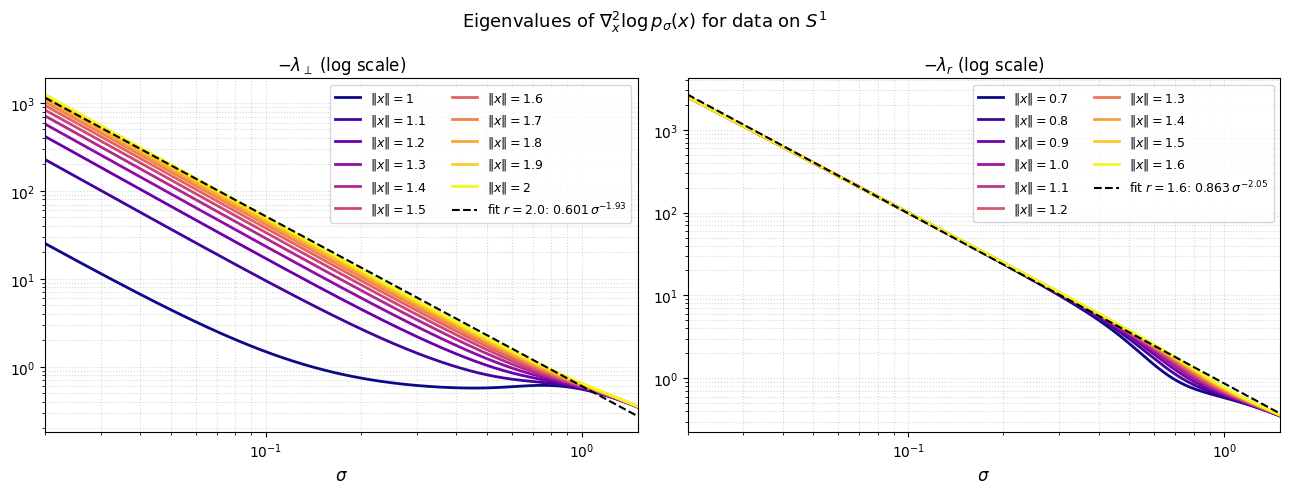

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import i0e, i1e

def bessel_ratio(lam):
    """A(λ) = I₁(λ)/I₀(λ) via scaled Bessels to avoid overflow at large λ."""
    return i1e(lam) / i0e(lam)

def hessian_eigenvalues(r, sigma):
    """
    Exact eigenvalues of ∇²log p_σ(x) for x with ‖x‖=r, data uniform on S¹.

    The Hessian has the form α I₂ + β x̂x̂ᵀ, giving eigenvalues:
      λ_tan = α          (tangential direction, multiplicity 1)
      λ_rad = α + β      (radial direction)
    """
    lam = r / sigma**2
    A = bessel_ratio(lam)
    alpha = (A / r - 1) / sigma**2
    beta  = (1 - 2 * sigma**2 * A / r - A**2) / sigma**4
    return alpha, alpha + beta

sigmas    = np.logspace(np.log10(0.02), np.log10(1.5), 600)
radii_tan = np.round([1.01] + list(np.arange(1.1, 2.01, 0.1)), 2)
radii_rad = np.round(np.arange(0.7, 1.61, 0.1), 1)
cmap      = plt.cm.plasma

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for i, r in enumerate(radii_tan):
    lam_tan, _ = hessian_eigenvalues(r, sigmas)
    color = cmap(i / (len(radii_tan) - 1))
    axes[0].plot(sigmas, -lam_tan, color=color, linewidth=2, label=rf'$\|x\|={r:.2g}$')

for i, r in enumerate(radii_rad):
    _, lam_rad = hessian_eigenvalues(r, sigmas)
    color = cmap(i / (len(radii_rad) - 1))
    axes[1].plot(sigmas, -lam_rad, color=color, linewidth=2, label=rf'$\|x\|={r:.1f}$')

# Power-law fits for r=1.6 in log-log space: log(-λ) = b·log(σ) + log(C)
for ax, vals in zip(axes, [
    -hessian_eigenvalues(2.0, sigmas)[0],   # -λ_tan at r=2.0
    -hessian_eigenvalues(1.6, sigmas)[1],   # -λ_rad at r=1.6
]):
    mask = vals > 0
    b, logC = np.polyfit(np.log(sigmas[mask]), np.log(vals[mask]), 1)
    C = np.exp(logC)
    fit_line = C * sigmas[mask] ** b
    r_fit = 2.0 if ax is axes[0] else 1.6
    ax.plot(sigmas[mask], fit_line, 'k--', linewidth=1.5,
            label=rf'fit $r={r_fit}$: ${C:.3f}\,\sigma^{{{b:.2f}}}$')

for ax, title in zip(axes, [r'$-\lambda_\perp$ (log scale)', r'$-\lambda_r$ (log scale)']):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\sigma$', fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9, ncol=2)
    ax.grid(True, linestyle=':', alpha=0.5, which='both')
    ax.set_xlim(sigmas[0], sigmas[-1])

fig.suptitle(
    r'Eigenvalues of $\nabla_x^2 \log p_\sigma(x)$ for data on $S^1$',
    fontsize=13,
)
plt.tight_layout()
plt.show()


# Circle analysis

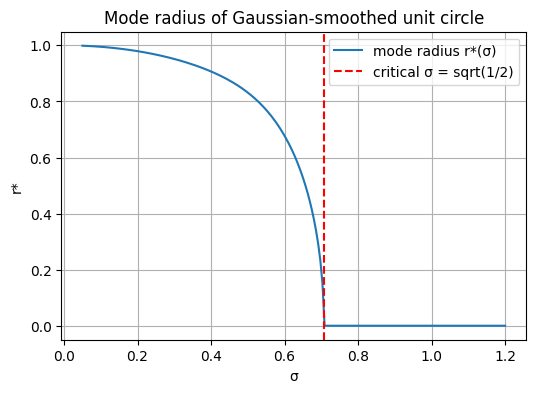

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from mpmath import besseli, findroot

def mode_r(sigma):
    # phase transition: mode collapses to 0
    if sigma**2 >= 0.5:
        return 0.0

    def F(r):
        return r - besseli(1, r/sigma**2) / besseli(0, r/sigma**2)

    # good initial guess: close to 1 for small sigma
    guess = max(0.1, 1 - sigma**2)

    try:
        r = findroot(F, guess)
        return float(r)
    except:
        # fallback coarse search
        rs = np.linspace(0, 1.5, 2000)
        vals = [abs(F(x)) for x in rs]
        return rs[int(np.argmin(vals))]

sigmas = np.linspace(0.05, 1.2, 200)
rs = [mode_r(s) for s in sigmas]

plt.figure(figsize=(6,4))
plt.plot(sigmas, rs, label="mode radius r*(σ)")
plt.axvline(np.sqrt(0.5), linestyle="--", color="red",
            label="critical σ = sqrt(1/2)")
plt.xlabel("σ")
plt.ylabel("r*")
plt.title("Mode radius of Gaussian-smoothed unit circle")
plt.legend()
plt.grid(True)
plt.show()

# Mode-radius collapse: wiggly circle

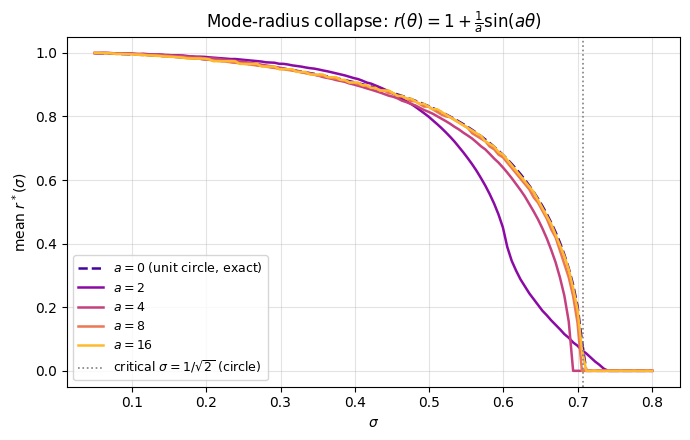

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from mpmath import besseli, findroot

# ── analytical unit-circle mode (Bessel formula) ─────────────────────────────
def mode_r_circle(sigma):
    if sigma**2 >= 0.5:
        return 0.0
    def F(r):
        return r - besseli(1, r / sigma**2) / besseli(0, r / sigma**2)
    guess = max(0.1, 1 - sigma**2)
    try:
        r = findroot(F, guess)
        return float(r)
    except:
        rs = np.linspace(0, 1.5, 2000)
        return rs[int(np.argmin([abs(F(x)) for x in rs]))]

# ── numerical mean mode radius for wiggly circle ─────────────────────────────
def mean_mode_r_wiggly(a, sigma, num_theta=300, num_rays=120, grid_res=250, limit=2.2):
    theta = np.linspace(0, 2 * np.pi, num_theta)
    r_true = 1 + (1.0 / a) * np.sin(a * theta)
    dr_dtheta = np.cos(a * theta)
    x_c = r_true * np.cos(theta)
    y_c = r_true * np.sin(theta)
    ds = np.sqrt(r_true**2 + dr_dtheta**2)

    phi = np.linspace(0, 2 * np.pi, num_rays, endpoint=False)
    R_span = np.linspace(0.0, limit * 0.95, grid_res)

    # density_ray[i, j] = unnorm density at radius R_span[i], angle phi[j]
    density_ray = np.zeros((grid_res, num_rays))
    for i in range(grid_res):
        Xr = (R_span[i] * np.cos(phi)).reshape(-1, 1)   # (num_rays, 1)
        Yr = (R_span[i] * np.sin(phi)).reshape(-1, 1)
        sq = (Xr - x_c) ** 2 + (Yr - y_c) ** 2          # (num_rays, num_theta)
        integrand = np.exp(-sq / (2 * sigma**2)) * ds
        density_ray[i, :] = np.trapezoid(integrand, x=theta, axis=-1)

    R_mode = R_span[np.argmax(density_ray, axis=0)]      # (num_rays,)
    return float(np.mean(R_mode))

# ── sweep σ ──────────────────────────────────────────────────────────────────
sigmas = np.linspace(0.05, 0.8,128)
a_values = [0, 2, 4, 8, 16]
colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(a_values)))

fig, ax = plt.subplots(figsize=(7, 4.5))

for a, col in zip(a_values, colors):
    if a == 0:
        rs = [mode_r_circle(s) for s in sigmas]
        label = r"$a=0$ (unit circle, exact)"
        ls = "--"
    else:
        rs = [mean_mode_r_wiggly(a, s) for s in sigmas]
        label = rf"$a={a}$"
        ls = "-"
    ax.plot(sigmas, rs, color=col, linestyle=ls, lw=1.8, label=label)

ax.axvline(np.sqrt(0.5), linestyle=":", color="gray", lw=1.2,
           label=r"critical $\sigma=1/\sqrt{2}$ (circle)")
ax.set_xlabel(r"$\sigma$")
ax.set_ylabel(r"mean $r^*(\sigma)$")
ax.set_title(r"Mode-radius collapse: $r(\theta)=1+\frac{1}{a}\sin(a\theta)$")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig("plots/08-mode-radius-collapse.png", dpi=150)
plt.show()


# 3-D Plotsimport numpy as np

In [13]:
import numpy as np
from scipy.special import ive
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ==================================================
# Circle radius
# ==================================================

R0 = 1.0

# ==================================================
# Stable Bessel ratios
# Uses exponentially-scaled Bessel functions
# to avoid overflow for small sigma.
# ==================================================

def A1(kappa):
    return ive(1, kappa) / ive(0, kappa)

def A2(kappa):
    return ive(2, kappa) / ive(0, kappa)

# ==================================================
# Posterior covariance eigenvalues
# ==================================================

def radial_cov(r, sigma):
    kappa = R0 * r / sigma**2

    a1 = A1(kappa)
    a2 = A2(kappa)

    return R0**2 * (
        0.5 * (1 + a2)
        - a1**2
    )

def tangential_cov(r, sigma):
    kappa = R0 * r / sigma**2

    a2 = A2(kappa)

    return R0**2 * (
        0.5 * (1 - a2)
    )

# ==================================================
# Hessian eigenvalues
# ==================================================

def lambda_r(r, sigma):
    return radial_cov(r, sigma) / sigma**4 - 1.0 / sigma**2

def lambda_t(r, sigma):
    return tangential_cov(r, sigma) / sigma**4 - 1.0 / sigma**2

# ==================================================
# Signed logarithm
# ==================================================

def slog(x):
    return np.sign(x) * np.log10(1.0 + np.abs(x))

# ==================================================
# Grid
# ==================================================

r_vals = np.linspace(0.5, 3.0, 250)

sigma_min = 0.05
sigma_max = 1.0

log_sigma_vals = np.linspace(
    np.log10(sigma_min),
    np.log10(sigma_max),
    250
)

sigma_vals = 10**log_sigma_vals

R, S = np.meshgrid(r_vals, sigma_vals)

# ==================================================
# Evaluate eigenvalues
# ==================================================

LR = lambda_r(R, S)
LT = lambda_t(R, S)

# ==================================================
# Coordinates for plotting
# Plot log10(sigma) on axis
# ==================================================

Y = np.log10(S)

# ==================================================
# Surface heights
# ==================================================

Zr = np.log10(-LR)
Zt = slog(LT)

absmax = np.max(np.abs(LT))

# ==================================================
# Figure with TWO independent 3D scenes
# ==================================================

fig = go.Figure()

# --------------------------------------------------
# Left plot (scene)
# --------------------------------------------------

fig.add_trace(
    go.Surface(
        x=R,
        y=Y,
        z=Zr,
        colorscale="Viridis",
        colorbar=dict(
            title="log10(-λr)",
            x=0.46
        ),
        scene="scene"
    )
)

# --------------------------------------------------
# Right plot (scene2)
# --------------------------------------------------

fig.add_trace(
    go.Surface(
        x=R,
        y=Y,
        z=Zt,
        surfacecolor=LT,
        colorscale="RdBu",
        cmin=-absmax,
        cmax=absmax,
        colorbar=dict(
            title="λt",
            x=1.0
        ),
        scene="scene2"
    )
)

# ==================================================
# Tick labels
# ==================================================

sigma_ticks = np.array([0.05,0.1,0.2,0.5,1.0])

sigma_tickvals = np.log10(sigma_ticks)
sigma_ticktext = [str(x) for x in sigma_ticks]

# ==================================================
# Camera
# ==================================================

camera = dict(
    eye=dict(
        x=5,
        y=5,
        z=3
    )
)

# ==================================================
# Layout
# ==================================================

fig.update_layout(

    width=2000,
    height=900,

    # LEFT SCENE
    scene=dict(

        domain=dict(
            x=[0.0, 0.48],
            y=[0.0, 1.0]
        ),

        xaxis_title="|x|",
        yaxis_title="σ",
        zaxis_title="log10(-λr)",

        yaxis=dict(
            tickvals=sigma_tickvals,
            ticktext=sigma_ticktext
        ),

        camera=camera,

        aspectmode="manual",
        aspectratio=dict(
            x=1.5,
            y=1.0,
            z=0.8
        )
    ),

    # RIGHT SCENE
    scene2=dict(

        domain=dict(
            x=[0.52, 1.0],
            y=[0.0, 1.0]
        ),

        xaxis_title="|x|",
        yaxis_title="σ",
        zaxis_title="slog(λt)",

        yaxis=dict(
            tickvals=sigma_tickvals,
            ticktext=sigma_ticktext
        ),

        camera=camera,

        aspectmode="manual",
        aspectratio=dict(
            x=1.5,
            y=1.0,
            z=0.8
        )
    ),

    margin=dict(
        l=0,
        r=0,
        t=30,
        b=0
    )
)

fig1.show()
fig2.show()